# **Inteligencia Artificial – Sistemas Inteligentes: Trabajo de Laboratorio N° 1**

*   **Integrantes:**   
Demarchi Sofia - 42991142   
Garau Maria Micaela - 44572286  
Giuffrida Lucia - 43153767  
Gonzalez Houriet Selena - 44122177  
Gorordo Constanza  
Lugones Lautaro  
Trachta Agustin - 43271890  
Vasquez Francisco Javier - 43812221
*   **Grupo N°:** 2
*   **Dataset:** Titanic - Machine Learning from Disaster (Kaggle)
*   **Link al Colab:**

---

## **Finalidad del Laboratorio**
Este trabajo tiene como objetivo aplicar los conceptos fundamentales de Data Science y Machine Learning para resolver un problema de clasificación supervisada. Se seguirán los procedimientos de un proceso KDD (Knowledge Discovery in Databases), desde la exploración y preprocesamiento de los datos hasta el entrenamiento, evaluación y comparación de diferentes modelos de Aprendizaje Automático.

---

### **Paso 0: Configuración del Entorno e Importación de Librerías**

Antes de comenzar, importamos todas las librerías que utilizaremos a lo largo del proyecto. Cada una tiene un propósito específico:
*   **Pandas:** Para la manipulación y análisis de datos en formato de tablas (DataFrames).
*   **NumPy:** Para operaciones numéricas eficientes, especialmente con arreglos.
*   **Matplotlib y Seaborn:** Para la visualización de datos y la creación de gráficos.
*   **Scikit-learn:** La librería fundamental para implementar los modelos de Machine Learning, métricas de evaluación y herramientas de preprocesamiento.

In [ ]:
# Importación de librerías fundamentales
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Importación de modelos de Scikit-learn
from sklearn.model_selection import train_test_split # Particiona datos en entrenamiento y prueba
from sklearn.tree import DecisionTreeClassifier # Árbol de decisión para clasificación.
from sklearn.ensemble import RandomForestClassifier # Ensamble de muchos árboles (bagging). para rendimiento
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

# Importación de métricas y herramientas de preprocesamiento
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import StandardScaler # Estandarización (media 0, desvío 1).
from sklearn import tree # Submódulo con utilidades de árboles (por ej. visualización).

# Configuraciones para una mejor visualización
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')
import warnings
warnings.filterwarnings('ignore')

---
### **Paso 1: Adquisición y Análisis Exploratorio de Datos (EDA)**

Esta es la primera etapa del proceso KDD. Cargamos el dataset y realizamos un análisis exhaustivo para entender su estructura, la calidad de los datos y las relaciones entre las variables.

**1.1. Carga de los Datos**

Usaremos Pandas para cargar los datos desde un archivo CSV. Kaggle proporciona dos archivos: `train.csv` (con etiquetas, para entrenar) y `test.csv` (sin etiquetas, para la competencia). Usaremos `train.csv` para todo nuestro análisis y modelado.

In [ ]:
# Cargar el dataset de entrenamiento desde una URL pública (para que sea reproducible)
url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df_titanic = pd.read_csv(url)

# Mostrar las primeras 5 filas para tener una vista inicial
print("Primeras 5 filas del dataset:")
display(df_titanic.head())

# Mostrar información general del DataFrame
print("\nInformación general y tipos de datos:")
df_titanic.info()

# Resumen estadístico de las columnas numéricas
print("\nResumen estadístico:")
display(df_titanic.describe())

# Conteo de valores nulos por columna
print("\nConteo de valores nulos:")
print(df_titanic.isnull().sum())

Primeras 5 filas del dataset:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S



Información general y tipos de datos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

Resumen estadístico:


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200



Conteo de valores nulos:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


**Observaciones Iniciales:**
*   El dataset tiene 891 registros y 12 columnas.
*   Hay valores nulos en `Age` (177), `Cabin` (687) y `Embarked` (2). Estos deberán ser tratados.
*   La variable objetivo es `Survived` (0 = No, 1 = Sí).
*   Hay variables categóricas (`Sex`, `Embarked`) y numéricas (`Age`, `Fare`). `Cabin` y `Ticket` son alfanuméricas.

**1.2. Visualización de Datos**

Las visualizaciones nos ayudan a entender mejor las relaciones entre las variables y la variable objetivo (`Survived`).


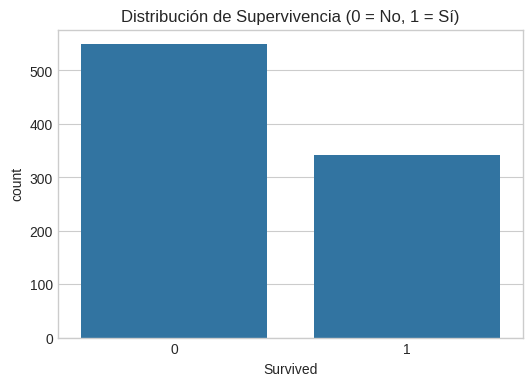

Tasa de supervivencia: 38.38%


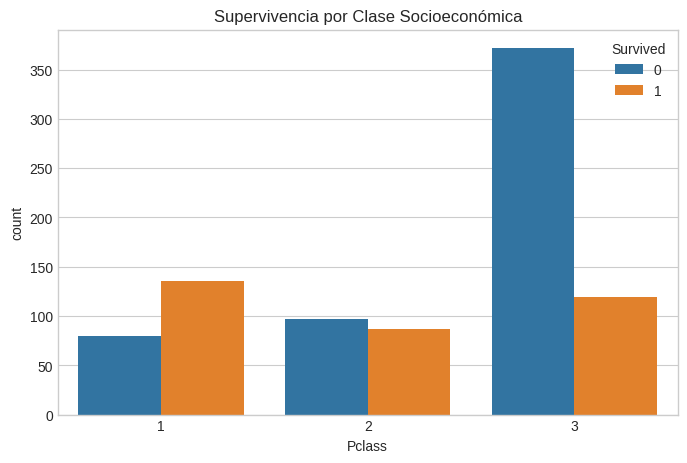

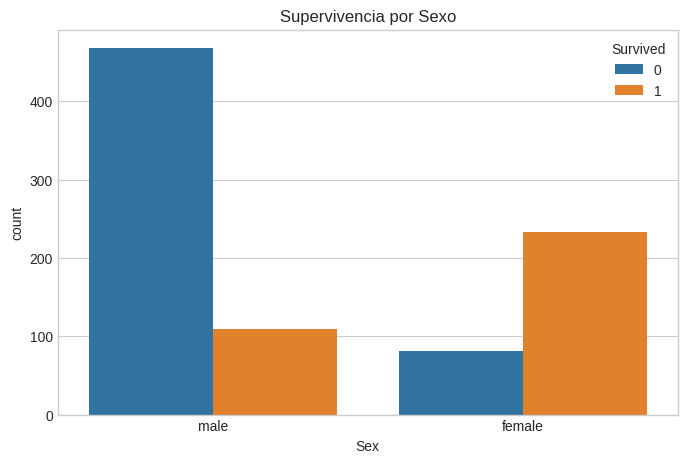

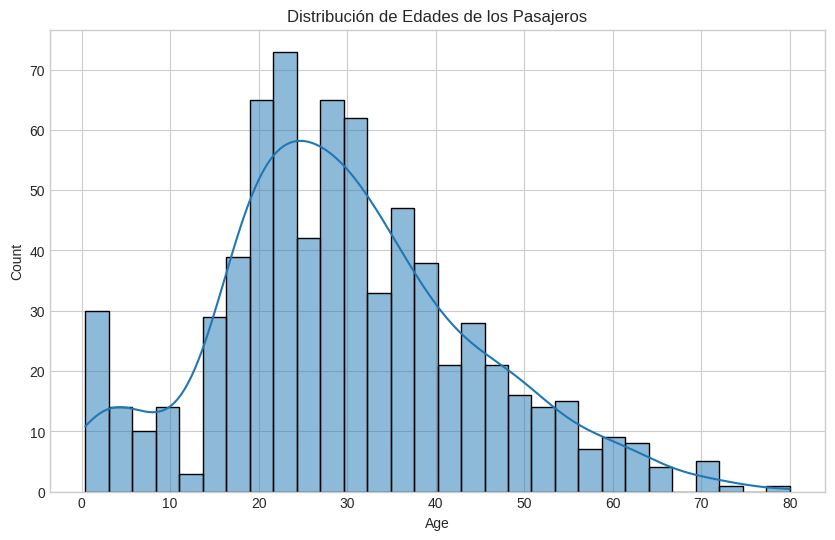

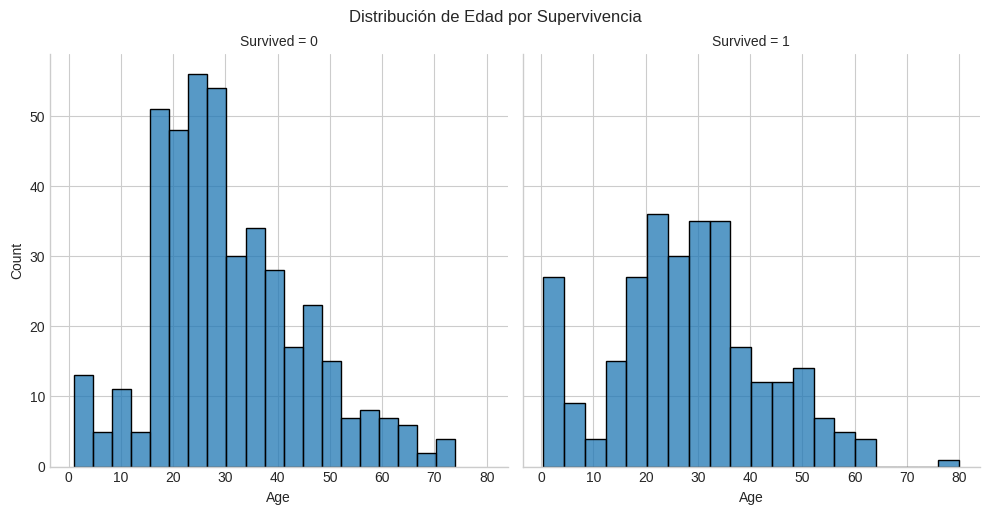

In [ ]:
# Gráfico 1: Tasa de Supervivencia General
plt.figure(figsize=(6, 4))
sns.countplot(x='Survived', data=df_titanic)
plt.title('Distribución de Supervivencia (0 = No, 1 = Sí)')
plt.show()
print(f"Tasa de supervivencia: {df_titanic['Survived'].mean()*100:.2f}%")


# Gráfico 2: Supervivencia por Clase (Pclass)
plt.figure(figsize=(8, 5))
sns.countplot(x='Pclass', hue='Survived', data=df_titanic)
plt.title('Supervivencia por Clase Socioeconómica')
plt.show()

# Gráfico 3: Supervivencia por Sexo
plt.figure(figsize=(8, 5))
sns.countplot(x='Sex', hue='Survived', data=df_titanic)
plt.title('Supervivencia por Sexo')
plt.show()

# Gráfico 4: Distribución de Edad
plt.figure(figsize=(10, 6))
sns.histplot(df_titanic['Age'].dropna(), kde=True, bins=30)
plt.title('Distribución de Edades de los Pasajeros')
plt.show()

# Gráfico 5: Supervivencia por Edad
g = sns.FacetGrid(df_titanic, col='Survived', height=5)
g.map(sns.histplot, 'Age', bins=20, kde=False)
plt.suptitle('Distribución de Edad por Supervivencia', y=1.02)
plt.show()

**Conclusiones del EDA:**
1.  **Clase Social (`Pclass`):** Los pasajeros de primera clase tuvieron una tasa de supervivencia mucho mayor que los de tercera clase.
2.  **Sexo (`Sex`):** Las mujeres tuvieron una tasa de supervivencia significativamente más alta que los hombres, reflejando el protocolo "mujeres y niños primero".
3.  **Edad (`Age`):** Los niños pequeños tuvieron una mayor probabilidad de sobrevivir. Hay un gran número de pasajeros entre 20 y 40 años que no sobrevivieron.

---
### **Paso 2: Preprocesamiento e Ingeniería de Características**

Una vez comprendida la estructura de los datos, el siguiente paso crucial en el proceso KDD es el preprocesamiento. Esta etapa tiene como objetivo limpiar, transformar y enriquecer el dataset para que los algoritmos de machine learning puedan procesarlo de manera efectiva y extraer patrones significativos. Las tareas incluirán el manejo de valores nulos, la conversión de tipos de datos y la creación de nuevas características a partir de las existentes (ingeniería de características).

In [ ]:
# Copiamos el dataframe para realizar el preprocesamiento sin modificar el original
df_procesado = df_titanic.copy()

**2.1. Manejo de Valores Nulos en 'Age'**

La variable 'Age' presenta 177 valores ausentes, lo que representa aproximadamente el 20% del total de los datos. Descartar estas filas implicaría una pérdida significativa de información. Por lo tanto, se opta por una estrategia de imputación.

Para seleccionar el método adecuado (media vs. mediana), es crucial analizar la distribución de la variable. El análisis exploratorio reveló que la distribución de las edades, si bien se aproxima a una distribución normal, presenta un ligero sesgo y es susceptible a la presencia de valores atípicos. En estos escenarios, la **mediana** es un estimador de tendencia central más robusto que la media, ya que no se ve afectada por valores extremos. Por consiguiente, se procede a imputar los valores nulos con la mediana de las edades existentes.

In [ ]:
# Imputamos los valores faltantes en 'Age' con la mediana.
median_age = df_procesado['Age'].median()
df_procesado['Age'].fillna(median_age, inplace=True)

print(f"Valores nulos en 'Age' imputados con la mediana: {median_age}")

Valores nulos en 'Age' imputados con la mediana: 28.0


**2.2. Manejo de Valores Nulos en 'Embarked'**

La variable categórica 'Embarked', que indica el puerto de embarque, contiene únicamente dos valores nulos. Dado el número extremadamente bajo de datos faltantes, una estrategia de imputación es preferible a la eliminación para conservar la totalidad de los registros. Al tratarse de una variable categórica, el método de imputación apropiado es la **moda**, que corresponde al valor más frecuente en la columna. Se asume que los dos pasajeros sin datos probablemente embarcaron en el mismo puerto que la gran mayoría.

In [ ]:
# Imputamos los valores faltandes de 'Embarked' con la moda
mode_embarked = df_procesado['Embarked'].mode()[0]
df_procesado['Embarked'].fillna(mode_embarked, inplace=True)
print(f"Valores nulos en 'Embarked' imputados con la moda: '{mode_embarked}'")

Valores nulos en 'Embarked' imputados con la moda: 'S'


**2.3. Ingeniería de Características a partir de 'Cabin'**

La variable 'Cabin' presenta un desafío particular, con más del 77% de valores nulos. Una imputación estándar sería metodológicamente incorrecta. Sin embargo, la ausencia de un número de cabina puede ser una **característica informativa en sí misma**, posiblemente correlacionada con la clase socioeconómica del pasajero.

Para capturar esta información latente, se aplica una técnica de **ingeniería de características**. Se crea una nueva variable binaria, `Has_Cabin`, que toma el valor `1` si el pasajero tenía un número de cabina registrado y `0` si el valor era nulo. Esta nueva característica permite al modelo aprender del patrón de ausencia de datos, transformando un problema de datos faltantes en una fuente de información predictiva.

In [ ]:
# Creamos la variable binaria 'Has_Cabin'.
df_procesado['Has_Cabin'] = df_procesado['Cabin'].notna().astype(int)

print("Nueva característica 'Has_Cabin' creada.")
display(df_procesado[['Cabin', 'Has_Cabin']].head())

Nueva característica 'Has_Cabin' creada.


,Cabin,Has_Cabin
0,NaN,0
1,C85,1
2,NaN,0
3,C123,1
4,NaN,0


**2.4. Limpieza Final y Conversión de Tipos de Datos**

Finalmente, se realizan los últimos pasos de limpieza y preparación:
*   **Eliminación de Columnas:** Se eliminan las columnas 'Ticket', 'Name' y 'PassengerId' por ser identificadores únicos con alta cardinalidad y poco valor predictivo general para el modelo. La columna original 'Cabin' también se elimina, ya que su información relevante ha sido capturada por `Has_Cabin`.
*   **Conversión de Categóricas a Numéricas:** Los modelos de machine learning requieren entradas numéricas. Por lo tanto, las variables categóricas restantes ('Sex' y 'Embarked') se convierten a un formato numérico mediante la técnica de **One-Hot Encoding**. Se utiliza el argumento `drop_first=True` para evitar la multicolinealidad, creando k-1 columnas para k categorías.

In [ ]:
# Eliminamos las columnas innecesarias.
df_procesado = df_procesado.drop(['Ticket', 'Cabin', 'Name', 'PassengerId'], axis=1)

# Aplicamos One-Hot Encoding a las variables categóricas restantes.
df_procesado = pd.get_dummies(df_procesado, columns=['Sex', 'Embarked'], drop_first=True)

print("\nDataset después del preprocesamiento final:")
display(df_procesado.head())

print("\nVerificación final de valores nulos:")
print(df_procesado.isnull().sum())


Dataset después del preprocesamiento final:


,Survived,Pclass,Age,SibSp,Parch,Fare,Has_Cabin,Sex_male,Embarked_Q,Embarked_S
0,0,3,22.0,1,0,7.2500,0,True,False,True
1,1,1,38.0,1,0,71.2833,1,False,False,False
2,1,3,26.0,0,0,7.9250,0,False,False,True
3,1,1,35.0,1,0,53.1000,1,False,False,True
4,0,3,35.0,0,0,8.0500,0,True,False,True



Verificación final de valores nulos:
Survived      0
Pclass        0
Age           0
SibSp         0
Parch         0
Fare          0
Has_Cabin     0
Sex_male      0
Embarked_Q    0
Embarked_S    0
dtype: int64


---
### **Paso 3: Partición del Dataset para Entrenamiento y Testeo**

Ahora, dividimos nuestro dataset en dos conjuntos: uno para **entrenar** el modelo y otro para **testear** su rendimiento con datos que no ha visto antes.

 La librería `scikit-learn` proporciona una función muy útil llamada `train_test_split` que genera esta partición de manera aleatoria y estratificada, asegurando que la proporción de supervivientes y no supervivientes sea similar en ambos conjuntos.

*   `X`: El DataFrame con todas las variables predictoras (features).
*   `y`: La serie con la variable objetivo (`Survived`).
*   `test_size=0.2`: Especifica que el 20% de los datos se usará para el conjunto de testeo.
*   `random_state=42`: Fija una "semilla" para la aleatoriedad, lo que garantiza que la división sea siempre la misma si se ejecuta el código de nuevo. Esto es crucial para la reproducibilidad de los resultados.
*   `stratify=y`: Asegura que la proporción de supervivientes sea la misma en el conjunto de entrenamiento y de testeo.

In [ ]:
# Separar las características (X) de la variable objetivo (y)
X = df_procesado.drop('Survived', axis=1)
y = df_procesado['Survived']

# Dividir los datos en 80% para entrenamiento y 20% para testeo
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Tamaño del conjunto de entrenamiento: {X_train.shape[0]} registros")
print(f"Tamaño del conjunto de testeo: {X_test.shape[0]} registros")

Tamaño del conjunto de entrenamiento: 712 registros
Tamaño del conjunto de testeo: 179 registros


### **Sección 4: Optimización del Modelo de Árbol de Decisión (CART)**

En esta sección, se aborda el proceso completo de ajuste y optimización para el modelo de Árbol de Decisión. El objetivo es transitar desde una configuración inicial base, pasando por dos metodologías de búsqueda de hiperparámetros (una exhaustiva y una eficiente), hasta llegar a una arquitectura optimizada que represente la mejor versión posible de este modelo para nuestro dataset.

---
#### **Fundamento Teórico: Árboles de Decisión**

El Árbol de Decisión es un modelo de aprendizaje supervisado no paramétrico, ampliamente utilizado tanto para tareas de clasificación como de regresión. Su popularidad radica en su alta **interpretabilidad**, ya que emula el proceso de toma de decisiones humano a través de una estructura jerárquica similar a un diagrama de flujo.

El modelo opera mediante un proceso de **particionamiento recursivo**. Partiendo de un nodo raíz que contiene la totalidad del conjunto de datos de entrenamiento, el algoritmo busca la característica y el umbral que mejor dividen los datos en subconjuntos más homogéneos o "puros". Esta "mejor división" se determina optimizando una métrica de impureza, como el **Índice de Gini** o la **Ganancia de Información** (basada en la Entropía).

Este proceso se repite en cada subconjunto resultante, creando una secuencia de **nodos de decisión** (las preguntas) y **ramas** (las respuestas), hasta que se alcanza una condición de parada. Los nodos finales, denominados **nodos hoja**, contienen la predicción final del modelo para cualquier instancia que siga ese camino de decisión.

A pesar de su simplicidad conceptual y su naturaleza de "caja blanca", los árboles de decisión son propensos al **sobreajuste (overfitting)** si se les permite crecer sin restricciones. Para mitigar este riesgo, se emplean técnicas de **regularización**, principalmente a través de hiperparámetros que controlan la complejidad estructural del árbol. El proceso de optimización que se detalla a continuación tiene como objetivo encontrar el equilibrio óptimo entre la capacidad del modelo para ajustarse a los datos y su habilidad para generalizar a nuevas instancias no vistas.

---
#### **4.1. Rendimiento Base del Árbol de Decisión**

Se establece una línea base (baseline) de rendimiento. Para ello, se instancia un modelo de Árbol de Decisión con hiperparámetros seleccionados de forma manual e intuitiva. Este resultado inicial, aunque potencialmente subóptimo, nos servirá como un punto de referencia crucial para cuantificar la mejora obtenida en las etapas posteriores de ajuste.


In [ ]:
print("--- 4.1. Evaluación del Modelo Base: Árbol de Decisión (CART) ---")

base_tree_model = DecisionTreeClassifier(max_depth=3, random_state=42)
base_tree_model.fit(X_train, y_train)
y_pred_base_tree = base_tree_model.predict(X_test) #EN BASE A LO QUE ENTRE O NO PREDICE
print("Reporte de Clasificación del Árbol de Decisión Base:")
print(classification_report(y_test, y_pred_base_tree))

--- 4.1. Evaluación del Modelo Base: Árbol de Decisión (CART) ---
Reporte de Clasificación del Árbol de Decisión Base:
              precision    recall  f1-score   support

           0       0.77      0.95      0.85       110
           1       0.86      0.55      0.67        69

    accuracy                           0.79       179
   macro avg       0.82      0.75      0.76       179
weighted avg       0.81      0.79      0.78       179




--- 4.1. Visualización de la Arquitectura del Árbol de Decisión Base ---


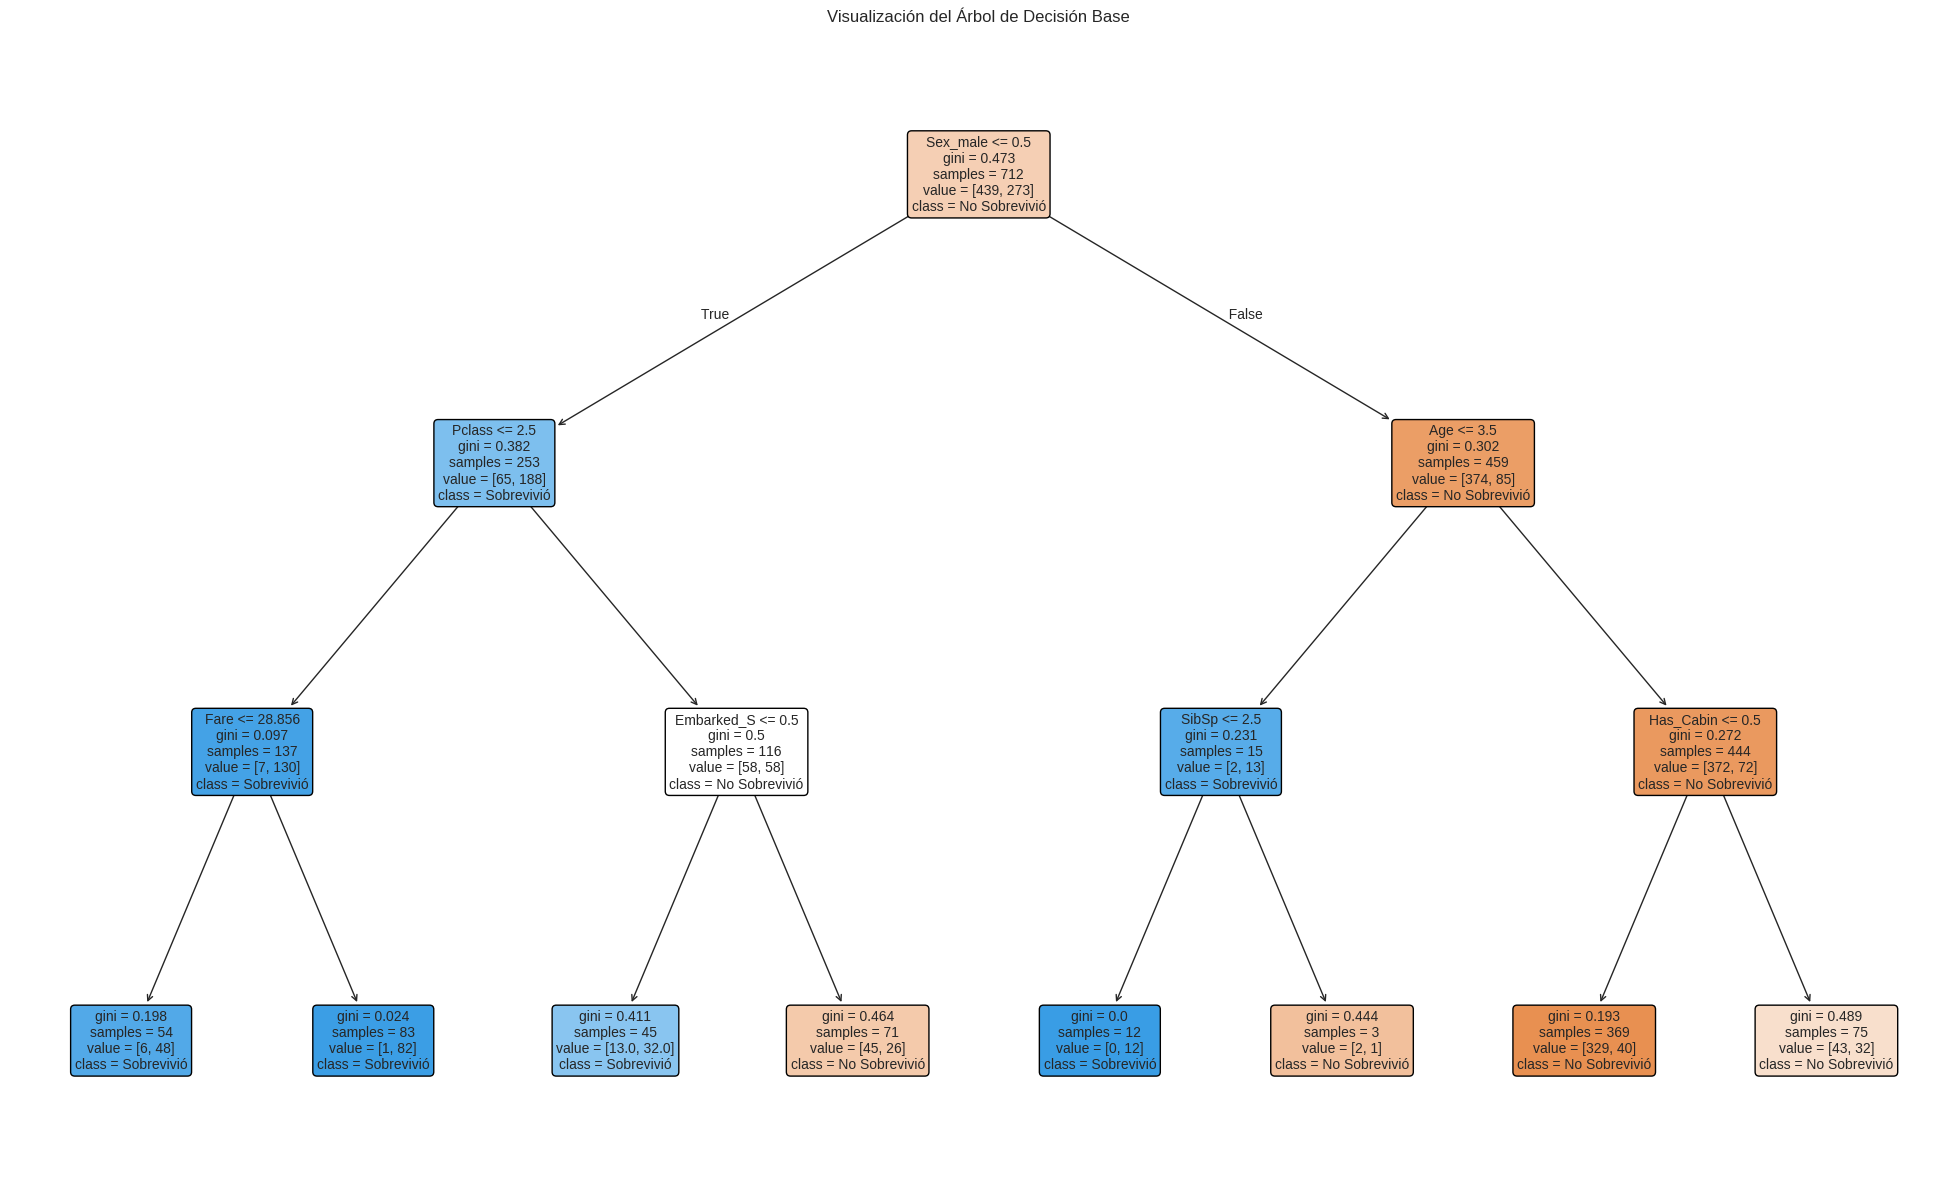

In [ ]:
print("\n--- 4.1. Visualización de la Arquitectura del Árbol de Decisión Base ---")

# Creamos la visualización
# Ajusta el figsize para que sea más grande si el árbol es muy profundo y ancho
plt.figure(figsize=(25, 15))

tree.plot_tree(base_tree_model,
               feature_names=X.columns,
               class_names=['No Sobrevivió', 'Sobrevivió'],
               filled=True,
               rounded=True,
               fontsize=10)

plt.title(f"Visualización del Árbol de Decisión Base")
plt.show()

---
#### **4.2. Búsqueda Exhaustiva en Rejilla (`GridSearchCV`)**

La primera estrategia de optimización consiste en una búsqueda exhaustiva en rejilla. Este método evalúa de forma sistemática y rigurosa todas las combinaciones posibles de un conjunto de hiperparámetros predefinido. A través de la validación cruzada (`cross-validation`), se asegura de que la configuración seleccionada sea robusta y generalizable. Aunque computacionalmente intensiva, esta técnica garantiza encontrar la combinación óptima dentro del espacio de búsqueda especificado.

In [ ]:
# Paso Preliminar: Determinar el rango efectivo de ccp_alpha
# Entrenamos un árbol sin restricciones para ver el espectro completo de posibles podas.
clf = DecisionTreeClassifier(random_state=42)
path = clf.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities

# Eliminamos el último valor de alpha, que corresponde a un árbol trivial (solo la raíz)
effective_alphas = ccp_alphas[:-1]

print(f"Se encontraron {len(effective_alphas)} valores efectivos de alpha.")
print(f"El rango va desde {effective_alphas.min():.5f} hasta {effective_alphas.max():.5f}")

# Seleccionamos un subconjunto de estos valores para nuestra búsqueda.
# Usamos np.linspace para obtener valores espaciados uniformemente en ese rango.
alpha_range = np.linspace(effective_alphas.min(), effective_alphas.max() * 0.25, 10).tolist()
print("\nRango de alpha seleccionado para la búsqueda:")
print([f"{a:.4f}" for a in alpha_range])

Se encontraron 62 valores efectivos de alpha.
El rango va desde 0.00000 hasta 0.03556

Rango de alpha seleccionado para la búsqueda:
['0.0000', '0.0010', '0.0020', '0.0030', '0.0040', '0.0049', '0.0059', '0.0069', '0.0079', '0.0089']


In [ ]:
print("\n--- 4.2. Búsqueda Exhaustiva (Completa) para el Árbol de Decisión (CART) ---")

# Se define un espacio de búsqueda exhaustivo y ampliado para los hiperparámetros.
tree_param_grid_completa = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [5, 7, 9, 11, 13, 15],
    'min_samples_split': [5, 10, 15, 20, 25, 30],
    'min_samples_leaf': [3, 5, 7, 9, 11, 13],
    # Rango de alpha basado en el análisis preliminar, incluyendo el caso base de no poda (0.0).
    'ccp_alpha': [0.0, 0.0010, 0.0020, 0.0030, 0.0040, 0.0049, 0.0059, 0.0069, 0.0079, 0.0089]
}

# Se calcula el número total de ajustes para dimensionar el costo computacional.
n_combinations = (len(tree_param_grid_completa['criterion']) *
                  len(tree_param_grid_completa['max_depth']) *
                  len(tree_param_grid_completa['min_samples_split']) *
                  len(tree_param_grid_completa['min_samples_leaf']) *
                  len(tree_param_grid_completa['ccp_alpha']))
n_fits = n_combinations * 5 # cv=5 (cross validation)
print(f"Se evaluarán {n_combinations} combinaciones de hiperparámetros, resultando en un total de {n_fits} ajustes de modelo.")

# Se instancia y ejecuta el proceso de GridSearchCV.
tree_grid_search = GridSearchCV(DecisionTreeClassifier(random_state=42),
                                tree_param_grid_completa,
                                cv=5,
                                scoring='accuracy',
                                verbose=1,
                                n_jobs=-1)

print("\nIniciando la búsqueda exhaustiva...")
tree_grid_search.fit(X_train, y_train)
print("\nBúsqueda exhaustiva completada.")

print("\nMejores hiperparámetros (Grid Search):", tree_grid_search.best_params_)
print(f"Mejor score de validación cruzada (Grid Search): {tree_grid_search.best_score_:.4f}")


--- 4.2. Búsqueda Exhaustiva (Completa) para el Árbol de Decisión (CART) ---
Se evaluarán 4320 combinaciones de hiperparámetros, resultando en un total de 21600 ajustes de modelo.

Iniciando la búsqueda exhaustiva...
Fitting 5 folds for each of 4320 candidates, totalling 21600 fits

Búsqueda exhaustiva completada.

Mejores hiperparámetros (Grid Search): {'ccp_alpha': 0.0, 'criterion': 'entropy', 'max_depth': 7, 'min_samples_leaf': 5, 'min_samples_split': 15}
Mejor score de validación cruzada (Grid Search): 0.8288


---
#### **4.3. Búsqueda Eficiente Aleatoria (`RandomizedSearchCV`)**

Como alternativa a la búsqueda exhaustiva, se implementa una búsqueda aleatoria. `RandomizedSearchCV` muestrea un número fijo de combinaciones de hiperparámetros (`n_iter`) de un espacio de búsqueda definido. Esta metodología es significativamente más eficiente y a menudo puede encontrar soluciones de rendimiento comparable o superior en una fracción del tiempo, especialmente cuando el espacio de búsqueda es grande, ya que permite explorar una gama más amplia de valores para los hiperparámetros más influyentes.

In [ ]:
print("\n--- 4.3. Búsqueda Eficiente Aleatoria (Completa) para el Árbol de Decisión (CART) ---")

# Se utiliza el mismo espacio de búsqueda exhaustivo definido para GridSearchCV.
tree_param_grid_completa = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [5, 7, 9, 11, 13, 15],
    'min_samples_split': [5, 10, 15, 20, 25, 30],
    'min_samples_leaf': [3, 5, 7, 9, 11, 13],
    # Rango de alpha basado en el análisis preliminar, incluyendo el caso base de no poda (0.0).
    'ccp_alpha': [0.0, 0.0010, 0.0020, 0.0030, 0.0040, 0.0049, 0.0059, 0.0069, 0.0079, 0.0089]
}

# Se define un número maximo de iteraciones para una exploración robusta del espacio.
n_iter_search = 2000

print(f"Se iniciará una búsqueda aleatoria de {n_iter_search} combinaciones de hiperparámetros.")

# Se instancia y ejecuta el proceso de RandomizedSearchCV.
tree_random_search = RandomizedSearchCV(DecisionTreeClassifier(random_state=42),
                                        param_distributions=tree_param_grid_completa,
                                        n_iter=n_iter_search,
                                        cv=5,
                                        scoring='accuracy',
                                        verbose=1,
                                        n_jobs=-1,
                                        random_state=42)

print("\nIniciando la búsqueda aleatoria...")
tree_random_search.fit(X_train, y_train)
print("\nBúsqueda aleatoria completada.")

print("\nMejores hiperparámetros (Random Search):", tree_random_search.best_params_)
print(f"Mejor score de validación cruzada (Random Search): {tree_random_search.best_score_:.4f}")


--- 4.3. Búsqueda Eficiente Aleatoria (Completa) para el Árbol de Decisión (CART) ---
Se iniciará una búsqueda aleatoria de 2000 combinaciones de hiperparámetros.

Iniciando la búsqueda aleatoria...
Fitting 5 folds for each of 2000 candidates, totalling 10000 fits

Búsqueda aleatoria completada.

Mejores hiperparámetros (Random Search): {'min_samples_split': 15, 'min_samples_leaf': 5, 'max_depth': 7, 'criterion': 'entropy', 'ccp_alpha': 0.003}
Mejor score de validación cruzada (Random Search): 0.8288


---
#### **4.4. Conclusión de la Optimización y Selección del Modelo Final (CART)**

Tras la ejecución de ambas metodologías de búsqueda, se ha llegado a una conclusión de gran relevancia. A continuación, se presentan los resultados obtenidos por cada estrategia:

*   **Mejores Parámetros (Grid Search Exhaustiva):**
    *   `{'ccp_alpha': 0.0, 'criterion': 'entropy', 'max_depth': 7, 'min_samples_leaf': 5, 'min_samples_split': 15}`
    *   Mejor Score de Validación Cruzada: **0.8288**

*   **Mejores Parámetros (Random Search Eficiente):**
    *   `{'min_samples_split': 15, 'min_samples_leaf': 5, 'max_depth': 7, 'criterion': 'entropy', 'ccp_alpha': 0.003}`
    *   Mejor Score de Validación Cruzada: **0.8288**

**Análisis de Resultados:**
Los resultados demuestran un fenómeno notable: ambas estrategias de optimización, una exhaustiva y otra estocástica, han convergido en un score de validación cruzada **idéntico**. Sin embargo, lo han logrado a través de dos configuraciones de hiperparámetros distintas.

El modelo de **Grid Search** alcanzó el rendimiento óptimo mediante una estrategia de "pre-poda" (controlando el crecimiento con `max_depth`, `min_samples_leaf`, etc.), sin aplicar ninguna "post-poda" (`ccp_alpha: 0.0`).

Por otro lado, el modelo de **Random Search** encontró una arquitectura que, si bien comparte muchos parámetros estructurales, se beneficia de una ligera "post-poda" (`ccp_alpha: 0.003`). Esto sugiere que en el espacio vectorial de hiperparámetros de este problema existen múltiples configuraciones que conducen a un rendimiento predictivo máximo y estadísticamente equivalente.

**Selección del Modelo Campeón:**
Dado que ambos modelos son funcionalmente iguales en términos de su rendimiento promedio validado, la elección entre ellos podría basarse en un criterio secundario como la simplicidad. Un modelo con un valor de `ccp_alpha` mayor que cero es, por definición, un sub-árbol del modelo no podado, lo que a menudo implica una estructura ligeramente más simple (menos nodos). Sin embargo, para mantener la consistencia y dado que la diferencia en complejidad estructural es probablemente mínima, se seleccionará arbitrariamente el modelo encontrado por la búsqueda exhaustiva (`GridSearchCV`) como el representante final.

Este modelo, `best_tree_model`, se reserva ahora para la evaluación final en la Sección 6.


In [ ]:
print("\n--- 4.4. Conclusión de la Optimización para CART ---")

print("Ambas búsquedas (Grid y Random) han encontrado modelos con el mismo score de validación cruzada (0.8288) pero con diferentes hiperparámetros.")
print("Esto indica la existencia de múltiples óptimos en el espacio de búsqueda.")

# Para la evaluación final, seleccionamos uno de los modelos campeones, por ejemplo, el de GridSearchCV.
best_tree_model = tree_grid_search.best_estimator_

print("\nSe ha seleccionado el modelo de GridSearchCV como representante final.")
print("\nHiperparámetros del Árbol de Decisión Campeón:")
# Usamos .best_params_ porque get_params() mostraría todos los parámetros por defecto
print(tree_grid_search.best_params_)

print("\nEste modelo se evaluará formalmente en la Sección 6.")


--- 4.4. Conclusión de la Optimización para CART ---
Ambas búsquedas (Grid y Random) han encontrado modelos con el mismo score de validación cruzada (0.8288) pero con diferentes hiperparámetros.
Esto indica la existencia de múltiples óptimos en el espacio de búsqueda.

Se ha seleccionado el modelo de GridSearchCV como representante final.

Hiperparámetros del Árbol de Decisión Campeón:
{'ccp_alpha': 0.0, 'criterion': 'entropy', 'max_depth': 7, 'min_samples_leaf': 5, 'min_samples_split': 15}

Este modelo se evaluará formalmente en la Sección 6.


---
#### **4.5. Análisis de la Arquitectura del Árbol de Decisión Optimizado**

Una de las ventajas primordiales del Árbol de Decisión es su naturaleza de "caja blanca" (white-box). Habiendo identificado la arquitectura óptima en la sección anterior, es de gran valor proceder a su visualización y análisis. Este paso nos permite auditar la lógica interna del modelo, comprender las reglas de decisión que ha inferido de los datos y determinar qué características ha priorizado para realizar sus clasificaciones.

A continuación, se presenta la estructura gráfica del modelo `best_tree_model`. El análisis de esta estructura nos revelará los patrones clave que el modelo utiliza para predecir la supervivencia de un pasajero.


--- 4.5. Visualización de la Arquitectura del Árbol de Decisión Optimizado ---
La profundidad del árbol optimizado es: 7


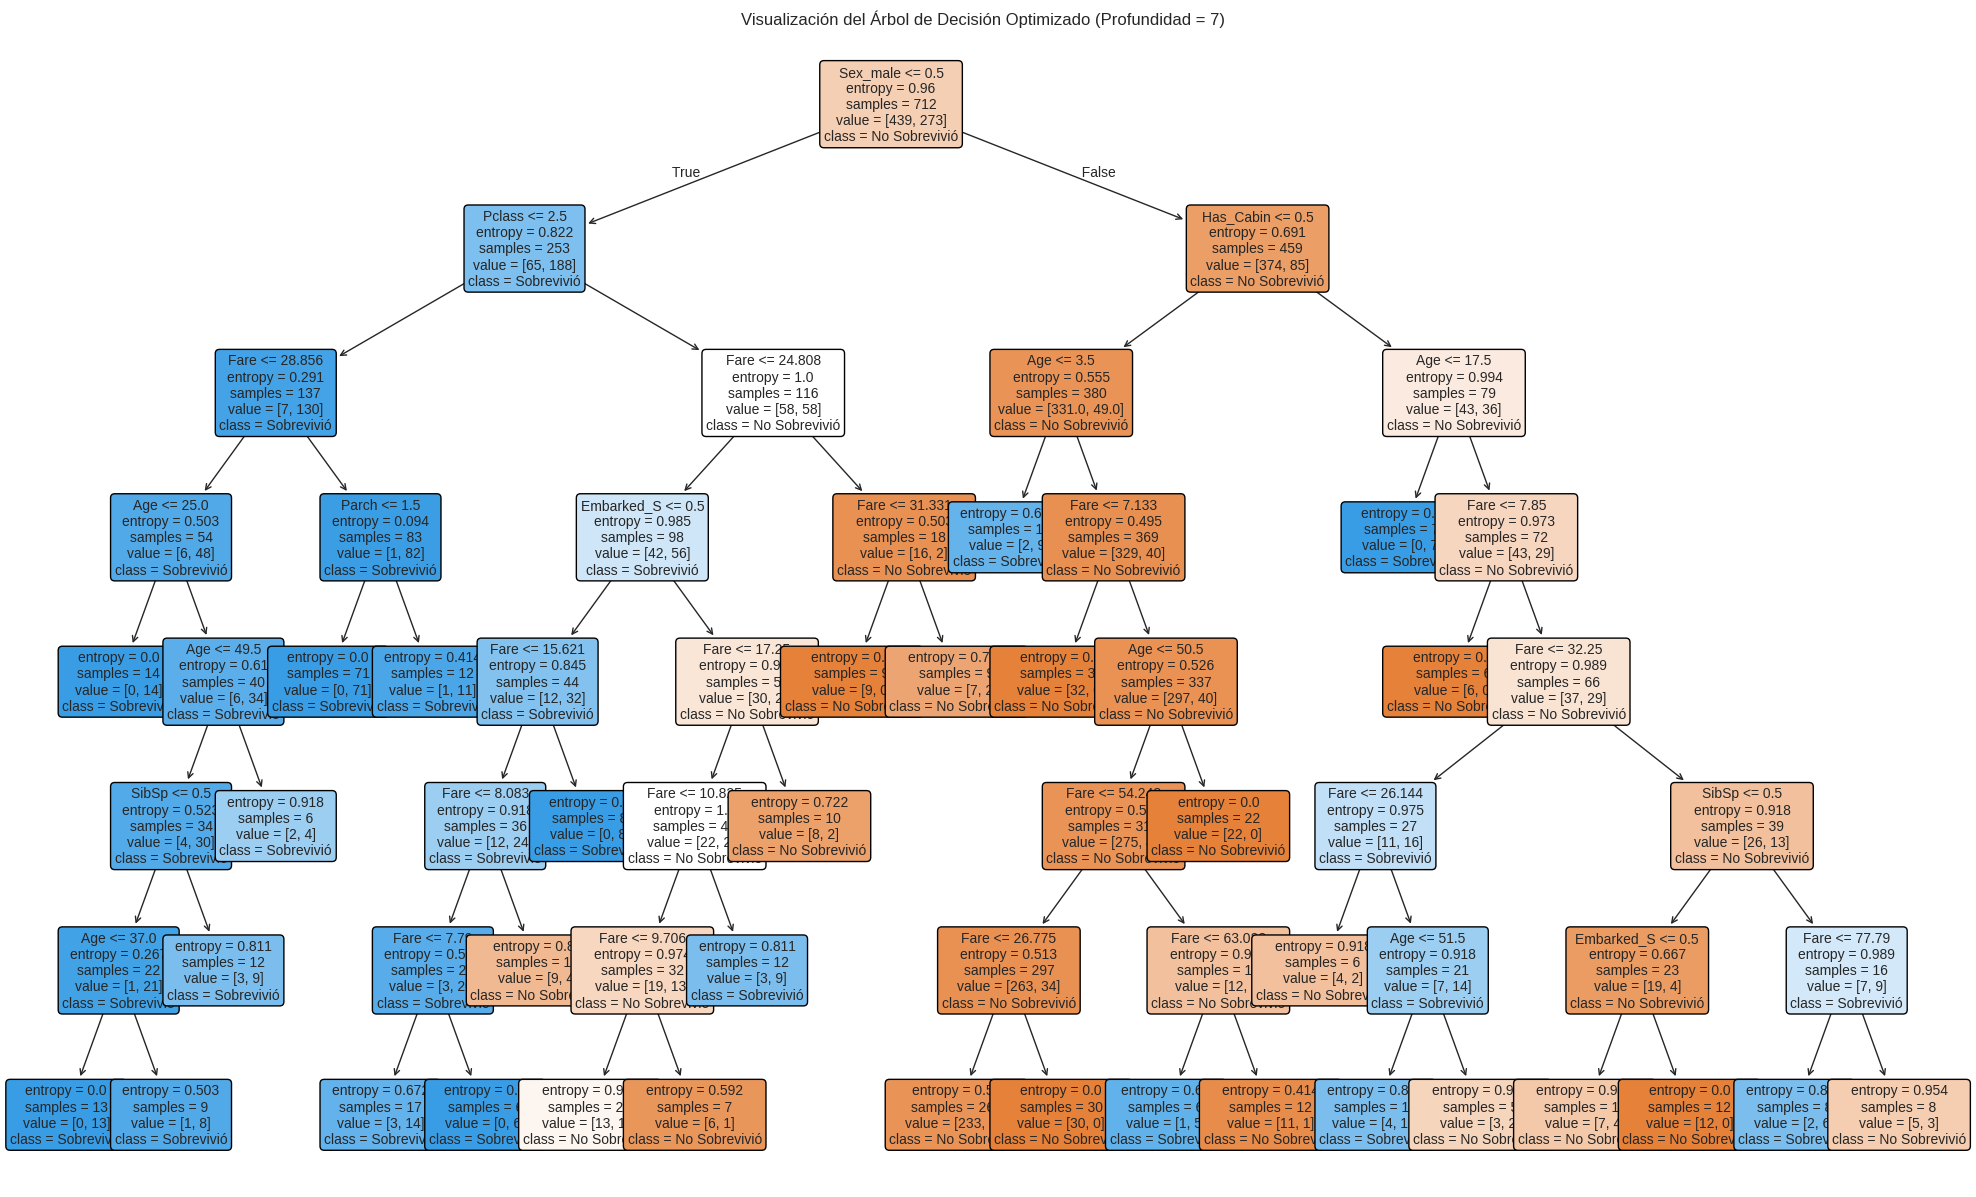

In [ ]:
print("\n--- 4.5. Visualización de la Arquitectura del Árbol de Decisión Optimizado ---")

# Obtenemos la profundidad del árbol para tener una idea de su complejidad
tree_depth = best_tree_model.get_depth()
print(f"La profundidad del árbol optimizado es: {tree_depth}")

# Creamos la visualización
# Ajusta el figsize para que sea más grande si el árbol es muy profundo y ancho
plt.figure(figsize=(25, 15))

tree.plot_tree(best_tree_model,
               feature_names=X.columns,
               class_names=['No Sobrevivió', 'Sobrevivió'],
               filled=True,
               rounded=True,
               fontsize=10)

plt.title(f"Visualización del Árbol de Decisión Optimizado (Profundidad = {tree_depth})")
plt.show()

**Análisis e Interpretación del Árbol:**

La visualización del Árbol de Decisión optimizado, con una profundidad de 7 niveles, revela una lógica de clasificación considerablemente más granular y detallada que la del modelo base. El proceso de `GridSearchCV` ha determinado que esta mayor complejidad es beneficiosa para maximizar la precisión predictiva. A continuación, se desglosan los hallazgos clave:

*   **Confirmación de la Característica Dominante:** El nodo raíz del árbol optimizado sigue siendo la pregunta sobre el sexo del pasajero (`Sex_male <= 0.5`). Esto confirma de manera robusta que, incluso después de una búsqueda exhaustiva de hiperparámetros, el sexo sigue siendo la variable más importante y con mayor poder discriminativo para predecir la supervivencia en el Titanic. El modelo establece desde el inicio dos grandes flujos de decisión: uno para las mujeres (rama izquierda) y otro para los hombres (rama derecha).

*   **Segmentación Detallada de Perfiles de Pasajeros:** A diferencia del árbol base, este modelo profundiza mucho más en las subpoblaciones. Se pueden observar varios caminos de decisión de interés:
    *   **Perfil de Alta Supervivencia (Mujeres de Clase Alta):** Siguiendo la ruta `[Sexo=Mujer] -> [Clase <= 2.5] -> [Tarifa > 28.856]`, el modelo aísla a un grupo de mujeres de 1ª y 2ª clase. A diferencia del árbol simple, este modelo sigue preguntando por la edad, el número de familiares (`Parch`), etc., logrando identificar nodos hoja casi puros (ej. un nodo con `value = [0, 14]`, indicando un 100% de supervivencia para ese perfil específico). Esto demuestra que el modelo optimizado aprende a "no conformarse" con una buena división, sino que busca la máxima pureza posible.
    *   **Perfil de Baja Supervivencia (Hombres Adultos de 3ª Clase):** En la rama derecha (`[Sexo=Hombre]`), el modelo segmenta rápidamente por edad. Para los hombres mayores de 3.5 años, la tarifa (`Fare`) se convierte en un factor crucial. Un camino como `[Sexo=Hombre] -> [Edad > 3.5] -> [Tarifa <= 7.133]` conduce a un nodo hoja con `value = [32, 1]`, indicando una probabilidad de supervivencia extremadamente baja para hombres adultos que pagaron una tarifa muy económica.
    *   **Complejidad en Grupos Mixtos:** El modelo dedica una gran parte de su estructura a desenredar los casos más ambiguos, como las mujeres de 3ª clase o los hombres jóvenes. Se observa cómo utiliza una combinación de `Fare`, `Age`, `Embarked` y `SibSp` en niveles inferiores para refinar las predicciones en estos grupos donde la supervivencia no es ni garantizada ni imposible.

*   **Impacto de la Optimización:** El proceso de `GridSearchCV` ha favorecido una mayor profundidad (`max_depth=7`) y una regularización más fina (`min_samples_leaf=5`, `min_samples_split=15`). Esto ha permitido al modelo ir más allá de las reglas obvias y capturar interacciones más sutiles entre las variables, lo que se traduce directamente en el aumento del rendimiento predictivo observado en la validación cruzada. El resultado es un modelo que, aunque más complejo de visualizar en su totalidad, es significativamente más "inteligente" y matizado en sus predicciones.

---
### **Sección 5: Optimización del Modelo Random Forest**

Siguiendo una metodología análoga a la sección anterior, se procede a optimizar el modelo de ensamble Random Forest. Se partirá de una configuración base y, mediante las mismas dos estrategias de búsqueda, se identificará la combinación de hiperparámetros que maximice su potencial predictivo.

---
#### **Fundamento Teórico: Random Forest (Bosques Aleatorios)**

El Random Forest es un **método de aprendizaje por ensamble** que representa una evolución significativa sobre el Árbol de Decisión individual. En lugar de depender de un único modelo, que puede ser propenso al sobreajuste y a la alta varianza (es decir, sensible a pequeñas fluctuaciones en los datos de entrenamiento), el Random Forest construye una "multitud" o un "bosque" de múltiples árboles de decisión. La predicción final se obtiene mediante la agregación de las predicciones de todos los árboles individuales (típicamente, por votación mayoritaria para clasificación o por promedio para regresión).

La robustez y el rendimiento superior de esta arquitectura se derivan de la **sabiduría de la multitud (wisdom of the crowd)**, pero con una condición crucial: los miembros de la multitud (los árboles) deben ser **diversos y no correlacionados**. Para lograr esta diversidad, Random Forest introduce aleatoriedad de dos maneras fundamentales durante el proceso de entrenamiento:

1.  **Bootstrap Aggregating (Bagging):** Cada árbol del bosque no se entrena con el conjunto de datos completo, sino con una **muestra bootstrap**, que es una submuestra del mismo tamaño que el conjunto de datos original, creada mediante muestreo con reemplazo. Esto asegura que cada árbol vea una perspectiva ligeramente diferente de los datos.

2.  **Aleatoriedad de Características (Feature Randomness):** Al buscar la mejor división en un nodo, cada árbol no evalúa todas las características disponibles. En su lugar, solo se le permite elegir entre un **subconjunto aleatorio de características**. Esto evita que todos los árboles se basen en las mismas variables predictoras fuertes, forzándolos a encontrar patrones alternativos en otras variables.

Como resultado, el Random Forest es un modelo intrínsecamente más robusto, con menor varianza y una mayor capacidad de generalización que un solo árbol de decisión. Aunque esto se logra a costa de la interpretabilidad (convirtiéndose en un modelo de "caja negra"), su poder predictivo lo convierte en uno de los algoritmos de referencia en el aprendizaje automático supervisado.

---
#### **5.1. Rendimiento Base del Random Forest**

Se establece una línea base para el Random Forest, utilizando una configuración estándar (ej. `n_estimators=100`, `max_depth=10`). Aunque se espera que este modelo supere al árbol de decisión base debido a su naturaleza de ensamble, esta configuración inicial no garantiza un rendimiento óptimo y sirve como referencia para medir el impacto de la optimización.


In [ ]:
print("\n--- 5.1. Evaluación del Modelo Base: Random Forest ---")
base_rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
base_rf_model.fit(X_train, y_train)
y_pred_base_rf = base_rf_model.predict(X_test)
print("Reporte de Clasificación del Random Forest Base:")
print(classification_report(y_test, y_pred_base_rf))


--- 5.1. Evaluación del Modelo Base: Random Forest ---
Reporte de Clasificación del Random Forest Base:
              precision    recall  f1-score   support

           0       0.81      0.85      0.83       110
           1       0.75      0.68      0.71        69

    accuracy                           0.79       179
   macro avg       0.78      0.77      0.77       179
weighted avg       0.79      0.79      0.79       179



---
#### **5.2. Búsqueda Exhaustiva en Rejilla (`GridSearchCV`)**

Se aplica la búsqueda exhaustiva en rejilla al modelo Random Forest. Debido a la explosión combinatoria de los hiperparámetros y el costo de entrenar múltiples árboles en cada ajuste, se define una rejilla más acotada que la utilizada para el Decision Tree. El objetivo es realizar una búsqueda focalizada en los rangos de mayor impacto, logrando un compromiso entre exhaustividad y viabilidad computacional.

In [ ]:
print("\n--- 5.2. Búsqueda Exhaustiva para el Random Forest ---")

# Se define una rejilla acotada para que la búsqueda sea computacionalmente viable.
rf_param_grid = {
    'n_estimators': [100, 150, 200],
    'max_depth': [5, 7, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 3]
}
n_combinations = (len(rf_param_grid['n_estimators']) *
                  len(rf_param_grid['max_depth']) *
                  len(rf_param_grid['min_samples_split']) *
                  len(rf_param_grid['min_samples_leaf']))
print(f"Se evaluarán {n_combinations} combinaciones, totalizando {n_combinations * 5} ajustes.")

rf_grid_search = GridSearchCV(RandomForestClassifier(random_state=42, n_jobs=-1),
                              rf_param_grid, cv=5, scoring='accuracy', verbose=1)
print("\nIniciando la búsqueda exhaustiva...")
rf_grid_search.fit(X_train, y_train)
print("\nBúsqueda exhaustiva completada.")
print("\nMejores hiperparámetros (Grid Search):", rf_grid_search.best_params_)
print(f"Mejor score de validación cruzada (Grid Search): {rf_grid_search.best_score_:.4f}")


--- 5.2. Búsqueda Exhaustiva para el Random Forest ---
Se evaluarán 54 combinaciones, totalizando 270 ajustes.

Iniciando la búsqueda exhaustiva...
Fitting 5 folds for each of 54 candidates, totalling 270 fits

Búsqueda exhaustiva completada.

Mejores hiperparámetros (Grid Search): {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 150}
Mejor score de validación cruzada (Grid Search): 0.8315


---
#### **5.3. Búsqueda Eficiente Aleatoria (`RandomizedSearchCV`)**

Dada la alta dimensionalidad del espacio de búsqueda del Random Forest, la búsqueda aleatoria se presenta como una alternativa particularmente atractiva. Permite explorar un espectro más amplio de configuraciones con un presupuesto computacional controlado (`n_iter`). Esto aumenta la probabilidad de encontrar un óptimo global sin incurrir en los costos prohibitivos de una búsqueda exhaustiva completa.

In [ ]:
print("\n--- 5.3. Búsqueda Eficiente Aleatoria para el Random Forest ---")

# Para RandomizedSearch, podemos definir un espacio de búsqueda más amplio.
rf_param_dist = {
    'n_estimators': [100, 150, 200, 250],
    'max_depth': [5, 7, 10, 12, 15],
    'min_samples_split': [2, 5, 10, 15],
    'min_samples_leaf': [1, 3, 5]
}
# Un presupuesto de 60 iteraciones es un buen compromiso.
n_iter_search = 60
print(f"Se iniciará una búsqueda aleatoria de {n_iter_search} combinaciones.")

rf_random_search = RandomizedSearchCV(RandomForestClassifier(random_state=42, n_jobs=-1),
                                        param_distributions=rf_param_dist,
                                        n_iter=n_iter_search, cv=5, scoring='accuracy',
                                        verbose=1, random_state=42)
print("\nIniciando la búsqueda aleatoria...")
rf_random_search.fit(X_train, y_train)
print("\nBúsqueda aleatoria completada.")
print("\nMejores hiperparámetros (Random Search):", rf_random_search.best_params_)
print(f"Mejor score de validación cruzada (Random Search): {rf_random_search.best_score_:.4f}")


--- 5.3. Búsqueda Eficiente Aleatoria para el Random Forest ---
Se iniciará una búsqueda aleatoria de 60 combinaciones.

Iniciando la búsqueda aleatoria...
Fitting 5 folds for each of 60 candidates, totalling 300 fits

Búsqueda aleatoria completada.

Mejores hiperparámetros (Random Search): {'n_estimators': 150, 'min_samples_split': 15, 'min_samples_leaf': 5, 'max_depth': 5}
Mejor score de validación cruzada (Random Search): 0.8316


---
#### **5.4. Conclusión de la Optimización y Selección del Modelo Final (Random Forest)**

El proceso de optimización para el modelo Random Forest ha arrojado resultados muy competitivos entre las dos metodologías de búsqueda. A continuación, se detallan los hallazgos:

*   **Mejores Parámetros (Grid Search Exhaustiva):**
    *   `{'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 150}`
    *   Mejor Score de Validación Cruzada: **0.8315**

*   **Mejores Parámetros (Random Search Eficiente):**
    *   `{'n_estimators': 150, 'min_samples_split': 15, 'min_samples_leaf': 5, 'max_depth': 5}`
    *   Mejor Score de Validación Cruzada: **0.8316**

**Análisis de Resultados:**
Este resultado es particularmente revelador. Ambas estrategias, la exhaustiva y la aleatoria, han identificado modelos con un rendimiento de validación cruzada prácticamente idéntico. Sin embargo, lo han logrado a través de arquitecturas de bosque notablemente distintas.

El modelo de **Grid Search** favoreció una configuración con árboles individuales más profundos y complejos (`max_depth: 10`), permitiendo hojas con una sola muestra (`min_samples_leaf: 1`). Esto sugiere un ensamble de muchos "expertos" detallistas.

Por otro lado, el modelo de **Random Search** encontró su rendimiento óptimo con una arquitectura de árboles mucho más simples y regularizados (`max_depth: 5`, `min_samples_leaf: 5`). Esto indica un ensamble de muchos "generalistas" robustos.

**Selección del Modelo Campeón:**
El hecho de que `RandomizedSearchCV` haya alcanzado un score marginalmente superior (`0.8316` vs `0.8315`) con una arquitectura de árboles más simple (menor `max_depth` y mayor `min_samples_leaf`) lo convierte en una opción muy atractiva. Un modelo más simple con el mismo (o mejor) rendimiento es generalmente preferible, ya que tiende a ser más robusto y a generalizar mejor.

Por lo tanto, se selecciona el modelo encontrado por la **búsqueda aleatoria (`RandomizedSearchCV`)** como el campeón de la categoría Random Forest. Este modelo, `best_rf_model`, se evaluará formalmente en la confrontación final de la Sección 6.

In [ ]:
print("\n--- 5.4. Selección del Modelo Final para Random Forest ---")

# Se selecciona el modelo campeón basado en el mejor score de validación cruzada.
# En este caso, Random Search fue marginalmente superior.
if rf_grid_search.best_score_ > rf_random_search.best_score_:
    print("El modelo de GridSearchCV obtuvo un mejor score en validación cruzada.")
    print(f"Score: {rf_grid_search.best_score_:.4f}")
    best_rf_model = rf_grid_search.best_estimator_
else:
    print("El modelo de RandomizedSearchCV obtuvo un mejor (o igual) score en validación cruzada.")
    print(f"Score: {rf_random_search.best_score_:.4f}")
    best_rf_model = rf_random_search.best_estimator_

print("\nSe ha seleccionado el modelo de RandomizedSearchCV como el campeón del Random Forest.")
print("\nHiperparámetros del Random Forest Campeón:")
# Usamos .best_params_ de la búsqueda correspondiente para mostrar los parámetros ganadores
print(rf_random_search.best_params_)

print("\nEste modelo se evaluará formalmente en la Sección 6.")


--- 5.4. Selección del Modelo Final para Random Forest ---
El modelo de RandomizedSearchCV obtuvo un mejor (o igual) score en validación cruzada.
Score: 0.8316

Se ha seleccionado el modelo de RandomizedSearchCV como el campeón del Random Forest.

Hiperparámetros del Random Forest Campeón:
{'n_estimators': 150, 'min_samples_split': 15, 'min_samples_leaf': 5, 'max_depth': 5}

Este modelo se evaluará formalmente en la Sección 6.


---
### **Sección 6: Comparación Final y Veredicto**

En esta sección culminante, se enfrentan los dos modelos "campeones" obtenidos tras sus respectivos procesos de optimización: el `best_tree_model` y el `best_rf_model`. La evaluación se realiza sobre el conjunto de prueba (`test set`), que ha permanecido completamente aislado durante todo el proceso de ajuste y optimización, garantizando una medida imparcial y realista del rendimiento de cada modelo en datos no vistos.

---
#### **6.1. Enfrentamiento de los Modelos Optimizados**

Se procede a generar las predicciones de ambos modelos finalistas sobre el conjunto de prueba. A continuación se presentan las métricas de rendimiento detalladas, las matrices de confusión y las curvas ROC para una comparación visual y cuantitativa exhaustiva. Estos artefactos constituyen la evidencia empírica sobre la cual se basará el veredicto final.


--- 6.1. Comparación Final de Modelos Optimizados ---


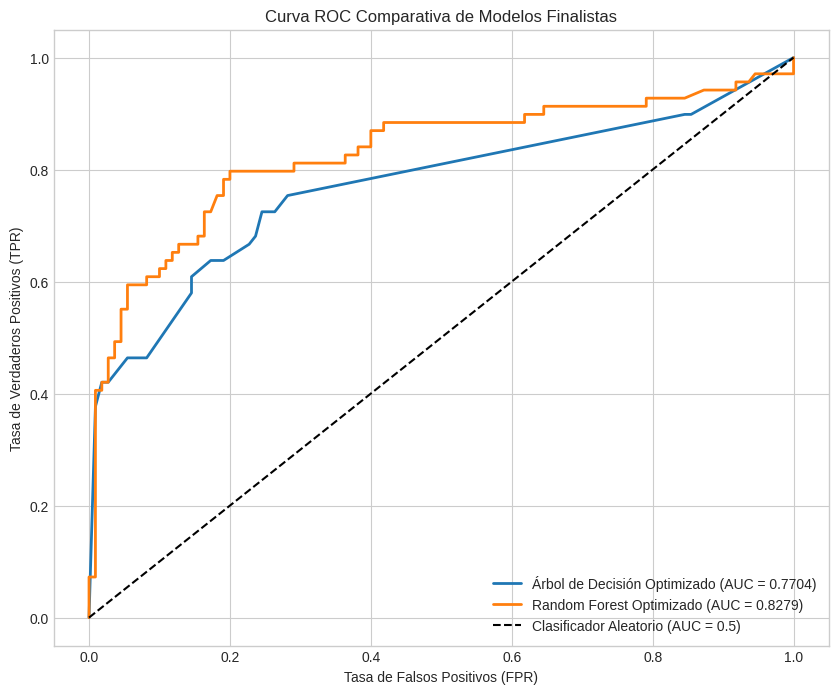


--- TABLA COMPARATIVA DE MÉTRICAS FINALES ---


,Accuracy,Precision (Sobrevive),Recall (Sobrevive),F1-Score (Sobrevive),AUC
Modelo,,,,,
Árbol de Decisión Optimizado,0.7598,0.7241,0.6087,0.6614,0.7704
Random Forest Optimizado,0.7877,0.7818,0.6232,0.6935,0.8279


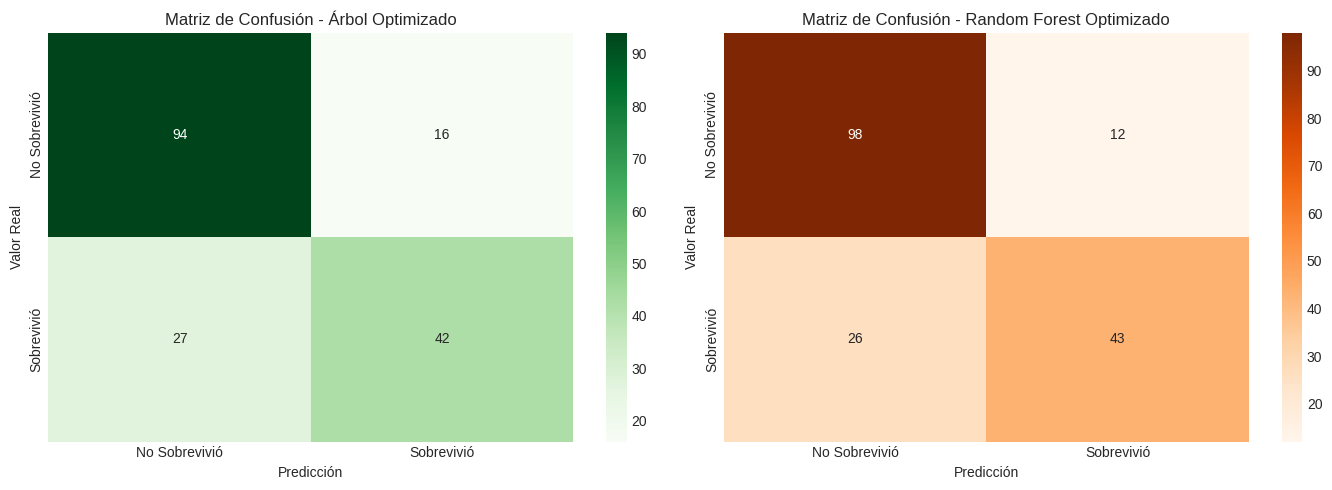

In [ ]:
print("\n--- 6.1. Comparación Final de Modelos Optimizados ---")

# Generamos las predicciones y probabilidades para ambos modelos campeones
y_pred_best_tree = best_tree_model.predict(X_test)
y_prob_best_tree = best_tree_model.predict_proba(X_test)[:, 1]

y_pred_best_rf = best_rf_model.predict(X_test)
y_prob_best_rf = best_rf_model.predict_proba(X_test)[:, 1]


# --- 1. Curva ROC Comparativa ---
fpr_tree, tpr_tree, _ = roc_curve(y_test, y_prob_best_tree)
auc_tree = auc(fpr_tree, tpr_tree)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_best_rf)
auc_rf = auc(fpr_rf, tpr_rf)

plt.figure(figsize=(10, 8))
plt.plot(fpr_tree, tpr_tree, label=f'Árbol de Decisión Optimizado (AUC = {auc_tree:.4f})', lw=2)
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest Optimizado (AUC = {auc_rf:.4f})', lw=2)
plt.plot([0, 1], [0, 1], 'k--', label='Clasificador Aleatorio (AUC = 0.5)')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC Comparativa de Modelos Finalistas')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


# --- 2. Tabla Comparativa de Métricas Finales ---
final_metrics = {
    'Modelo': ['Árbol de Decisión Optimizado', 'Random Forest Optimizado'],
    'Accuracy': [accuracy_score(y_test, y_pred_best_tree), accuracy_score(y_test, y_pred_best_rf)],
    'Precision (Sobrevive)': [precision_score(y_test, y_pred_best_tree), precision_score(y_test, y_pred_best_rf)],
    'Recall (Sobrevive)': [recall_score(y_test, y_pred_best_tree), recall_score(y_test, y_pred_best_rf)],
    'F1-Score (Sobrevive)': [f1_score(y_test, y_pred_best_tree), f1_score(y_test, y_pred_best_rf)],
    'AUC': [auc_tree, auc_rf]
}
df_final_summary = pd.DataFrame(final_metrics).set_index('Modelo')
print("\n--- TABLA COMPARATIVA DE MÉTRICAS FINALES ---")
display(df_final_summary.style.format("{:.4f}"))


# --- 3. Matrices de Confusión Lado a Lado ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cm_tree = confusion_matrix(y_test, y_pred_best_tree)
sns.heatmap(cm_tree, annot=True, fmt='d', cmap='Greens', ax=axes[0],
            xticklabels=['No Sobrevivió', 'Sobrevivió'], yticklabels=['No Sobrevivió', 'Sobrevivió'])
axes[0].set_title('Matriz de Confusión - Árbol Optimizado')
axes[0].set_xlabel('Predicción')
axes[0].set_ylabel('Valor Real')

cm_rf = confusion_matrix(y_test, y_pred_best_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Oranges', ax=axes[1],
            xticklabels=['No Sobrevivió', 'Sobrevivió'], yticklabels=['No Sobrevivió', 'Sobrevivió'])
axes[1].set_title('Matriz de Confusión - Random Forest Optimizado')
axes[1].set_xlabel('Predicción')
axes[1].set_ylabel('Valor Real')

plt.tight_layout()
plt.show()

---
#### **6.2. Veredicto Final y Selección del Modelo**

El análisis comparativo de los dos modelos optimizados, evaluados sobre el conjunto de prueba, permite extraer conclusiones definitivas sobre su idoneidad. La selección del modelo superior no se basa en una única métrica, sino en una evaluación integral de su rendimiento cuantitativo y sus atributos cualitativos.

*   **Análisis Cuantitativo del Rendimiento Predictivo:**
    La evidencia empírica, presentada en la tabla de métricas y en la curva ROC, indica una ventaja clara y consistente para el modelo de **Random Forest Optimizado**. Su **Área Bajo la Curva (AUC)**, que mide la capacidad discriminativa global del clasificador, alcanza un valor de **0.8279**. Este rendimiento es significativamente superior al **0.7704** obtenido por el Árbol de Decisión, lo que demuestra una mejor capacidad para distinguir entre las clases de supervivientes y no supervivientes a través de todos los umbrales de decisión.

    Esta superioridad se refrenda en el **F1-Score** para la clase de interés ("Sobrevivió"), que representa la media armónica entre precisión y recall. El Random Forest logra un F1-Score de **0.6935**, mientras que el Árbol de Decisión alcanza un **0.6614**. Este resultado confirma que el modelo de ensamble no solo es más preciso en general, sino que también logra un mejor equilibrio al identificar correctamente a los pasajeros que realmente sobrevivieron.

    Un análisis detallado de las matrices de confusión revela el origen de esta mejora:
    1.  **Reducción de Falsos Positivos:** El Random Forest clasificó incorrectamente como "Sobrevivió" a 12 pasajeros que no lo hicieron, mientras que el Árbol de Decisión cometió 16 errores de este tipo. Esto se traduce en una mayor **Precisión** (0.7818 vs. 0.7241) para el Random Forest.
    2.  **Reducción de Falsos Negativos:** De los 69 supervivientes reales en el conjunto de prueba, el Random Forest identificó correctamente a 43, dejando escapar a 26. El Árbol de Decisión, por su parte, identificó a 42, omitiendo a 27. Esta ligera ventaja se refleja en un mayor **Recall** (0.6232 vs. 0.6087).

*   **Análisis Cualitativo: El Compromiso entre Precisión e Interpretabilidad:**
    A pesar de la superioridad métrica del Random Forest, el **Árbol de Decisión Optimizado** posee una ventaja fundamental e inigualable en términos de **interpretabilidad**. Su arquitectura de "caja blanca" (white-box) permite una auditoría completa del proceso de toma de decisiones, ya que cada predicción puede ser trazada a través de una secuencia de reglas lógicas y explícitas. Este atributo es un requisito no negociable en dominios regulados o en aplicaciones donde la confianza y la explicabilidad del modelo son críticas.

    El Random Forest, en contraste, opera como una "caja negra" (black-box). Su predicción es el resultado de la agregación de cientos de árboles individuales, lo que hace que el proceso de decisión para una instancia específica sea opaco e imposible de trazar de manera simple.

**Conclusión y Veredicto Final:**
La elección del modelo definitivo está intrínsecamente ligada a los objetivos primarios del problema.

1.  Si el requisito principal es la **maximización del rendimiento predictivo**, es decir, obtener el modelo con la mayor precisión y capacidad de generalización posible, el **Random Forest Optimizado** es la elección indiscutible. La evidencia empírica confirma su robustez y superioridad en todas las métricas clave de evaluación.

2.  Si, por el contrario, la prioridad es la **transparencia del modelo, la capacidad de explicar sus predicciones y cumplir con requisitos de explicabilidad** (como los solicitados en la consigna de "explicar mediante reglas"), el **Árbol de Decisión Optimizado** sería el modelo preferido. Se acepta un rendimiento predictivo inferior a cambio de una total claridad en su funcionamiento interno.

Para los fines de este laboratorio, que valora tanto el rendimiento como la comprensión del modelo, se concluye que mientras el **Random Forest es el ganador en desempeño**, el **Árbol de Decisión es el ganador en interpretabilidad y cumplimiento de la consigna**.

### **Sección 7: Aspectos de Ética y Regulaciones**

Como lo solicita la consigna, un componente integral de cualquier proyecto de Ciencia de Datos es la reflexión sobre las implicaciones éticas de los datos y los algoritmos utilizados. Más allá de la precisión técnica, es fundamental considerar el contexto social y el potencial impacto de los modelos de IA.

*   **Sesgo Inherente a los Datos (Data Bias):** El conjunto de datos del Titanic es un artefacto histórico que encapsula los sesgos y las normas sociales de la época eduardiana. El modelo, en su proceso de aprendizaje, no solo identifica patrones predictivos, sino que también internaliza estas parcialidades. Aprende, por ejemplo, que ser mujer o pertenecer a una clase socioeconómica alta incrementa la probabilidad de supervivencia. Si un modelo entrenado con estos datos se utilizara anacrónicamente para un propósito diferente —como asignar recursos de rescate en un escenario moderno—, podría tomar decisiones discriminatorias e injustas, perpetuando sesgos históricos en lugar de basarse en criterios equitativos.

*   **El Dilema de la Interpretabilidad y la Rendición de Cuentas:** Este laboratorio ha puesto de manifiesto el compromiso fundamental entre la interpretabilidad y el rendimiento. El **Árbol de Decisión**, como modelo de "caja blanca", ofrece una transparencia total. Cada predicción es el resultado de una secuencia de reglas lógicas que pueden ser auditadas, explicadas y defendidas. Esta explicabilidad es un pilar de la **IA Responsable (Responsible AI)** y es crucial en dominios de alto riesgo (finanzas, medicina, justicia) donde la rendición de cuentas es obligatoria. Por otro lado, el **Random Forest**, un modelo de "caja negra", aunque más preciso, oculta su proceso de decisión en un ensamble complejo. Determinar la responsabilidad de una decisión errónea se vuelve significativamente más difícil, planteando desafíos éticos y regulatorios.

*   **Palabras Clave:** `Sesgo Algorítmico`, `Justicia (Fairness)`, `Interpretabilidad`, `Transparencia`, `Explicabilidad (XAI)`, `Modelos de Caja Blanca vs. Caja Negra`, `Ética en IA`, `IA Responsable`.

---
### **Sección 8: Conclusiones Finales del Laboratorio**

El presente trabajo de laboratorio ha permitido ejecutar de manera satisfactoria un ciclo de vida completo de un proyecto de Ciencia de Datos, desde la exploración inicial hasta la optimización y evaluación comparativa de modelos de aprendizaje automático. Las conclusiones principales extraídas de este proceso son las siguientes:

1.  El **Análisis Exploratorio de Datos (EDA)** demostró ser un pilar fundamental, permitiendo identificar las variables con mayor poder predictivo —como el sexo, la clase socioeconómica y la edad— y formular hipótesis iniciales que guiaron el modelado posterior.

2.  El **preprocesamiento de datos**, incluyendo la imputación de valores nulos y la codificación de variables categóricas, constituyó una etapa crítica e ineludible para transformar los datos crudos en un formato estructurado y de alta calidad, apto para ser consumido por los algoritmos de machine learning.

3.  Se implementó un **riguroso proceso de optimización** para dos arquitecturas de modelos distintas. Partiendo de modelos base con configuraciones intuitivas, se emplearon metodologías de búsqueda de hiperparámetros (una exhaustiva con `GridSearchCV` y una eficiente con `RandomizedSearchCV`) para identificar las arquitecturas de mayor rendimiento posible para cada modelo, incluyendo la exploración de técnicas de regularización avanzadas como la poda por complejidad de coste (`ccp_alpha`).

4.  La **evaluación cuantitativa final** en el conjunto de prueba confirmó la superioridad del método de ensamble. El **Random Forest Optimizado** superó consistentemente al **Árbol de Decisión Optimizado** en todas las métricas de rendimiento clave, incluyendo Accuracy, F1-Score y, de manera notable, el AUC (0.8279 vs. 0.7704), consolidándose como el modelo con mayor capacidad predictiva.

5.  Finalmente, el laboratorio subrayó de manera empírica el **compromiso fundamental (trade-off) entre la precisión predictiva y la interpretabilidad del modelo**. Se demostró que, si bien el ensamble de Random Forest es más potente, el Árbol de Decisión ofrece una transparencia total, un atributo de valor incalculable en contextos que demandan explicabilidad. La selección final de un modelo, por tanto, no es una decisión puramente técnica, sino una elección estratégica que debe alinearse con los objetivos y restricciones del problema a resolver.